In [130]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

In [131]:
dataArray = pd.read_excel("practica2.xlsx", sheet_name="pyin1", header = None, decimal = ",").to_numpy()

In [132]:
largeDataArray = np.vstack((dataArray, np.flipud(dataArray[:-1,:])))
largerDataArray = np.hstack((largeDataArray, -np.fliplr(largeDataArray[:,:-1]) + 9.53*2-0.3))

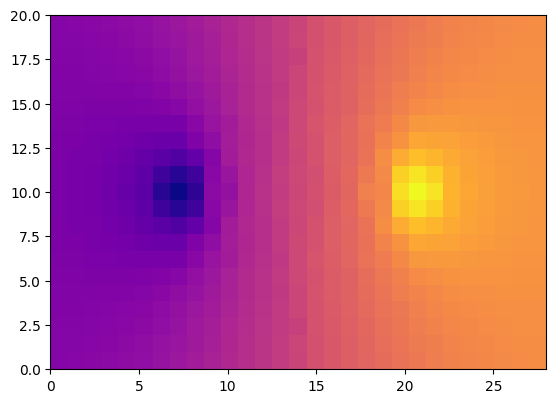

In [133]:
plt.imshow(largerDataArray, aspect='equal', cmap = "plasma", origin = "lower", interpolation = "nearest", extent = (0,28,0,20))

plt.show()

In [134]:
xGrid = np.arange(0, largerDataArray.shape[1], step = 1)
yGrid = np.arange(0, largerDataArray.shape[0], step = 1)

In [135]:
interp = sp.interpolate.RegularGridInterpolator((yGrid, xGrid), largerDataArray, method = "linear")

In [136]:
xplot = np.linspace(xGrid.min(), xGrid.max(), 560)
yplot = np.linspace(yGrid.min(), yGrid.max(), 400)

X, Y = np.meshgrid(xplot, yplot, indexing='xy')
data = interp((Y, X))

In [137]:
realSpacingInXplotSpace = xGrid.size/xplot.size
realSpacingInYplotSpace = yGrid.size/yplot.size

fieldGradient = -np.array(np.gradient(data, realSpacingInYplotSpace, realSpacingInXplotSpace)) #unidades de voltio /

In [138]:
colors = ["#03071e","#370617","#6a040f","#9d0208","#d00000","#dc2f02","#e85d04","#f48c06","#faa307"]
red_orange_cmap = mpl.colors.LinearSegmentedColormap.from_list("red_orange", colors)

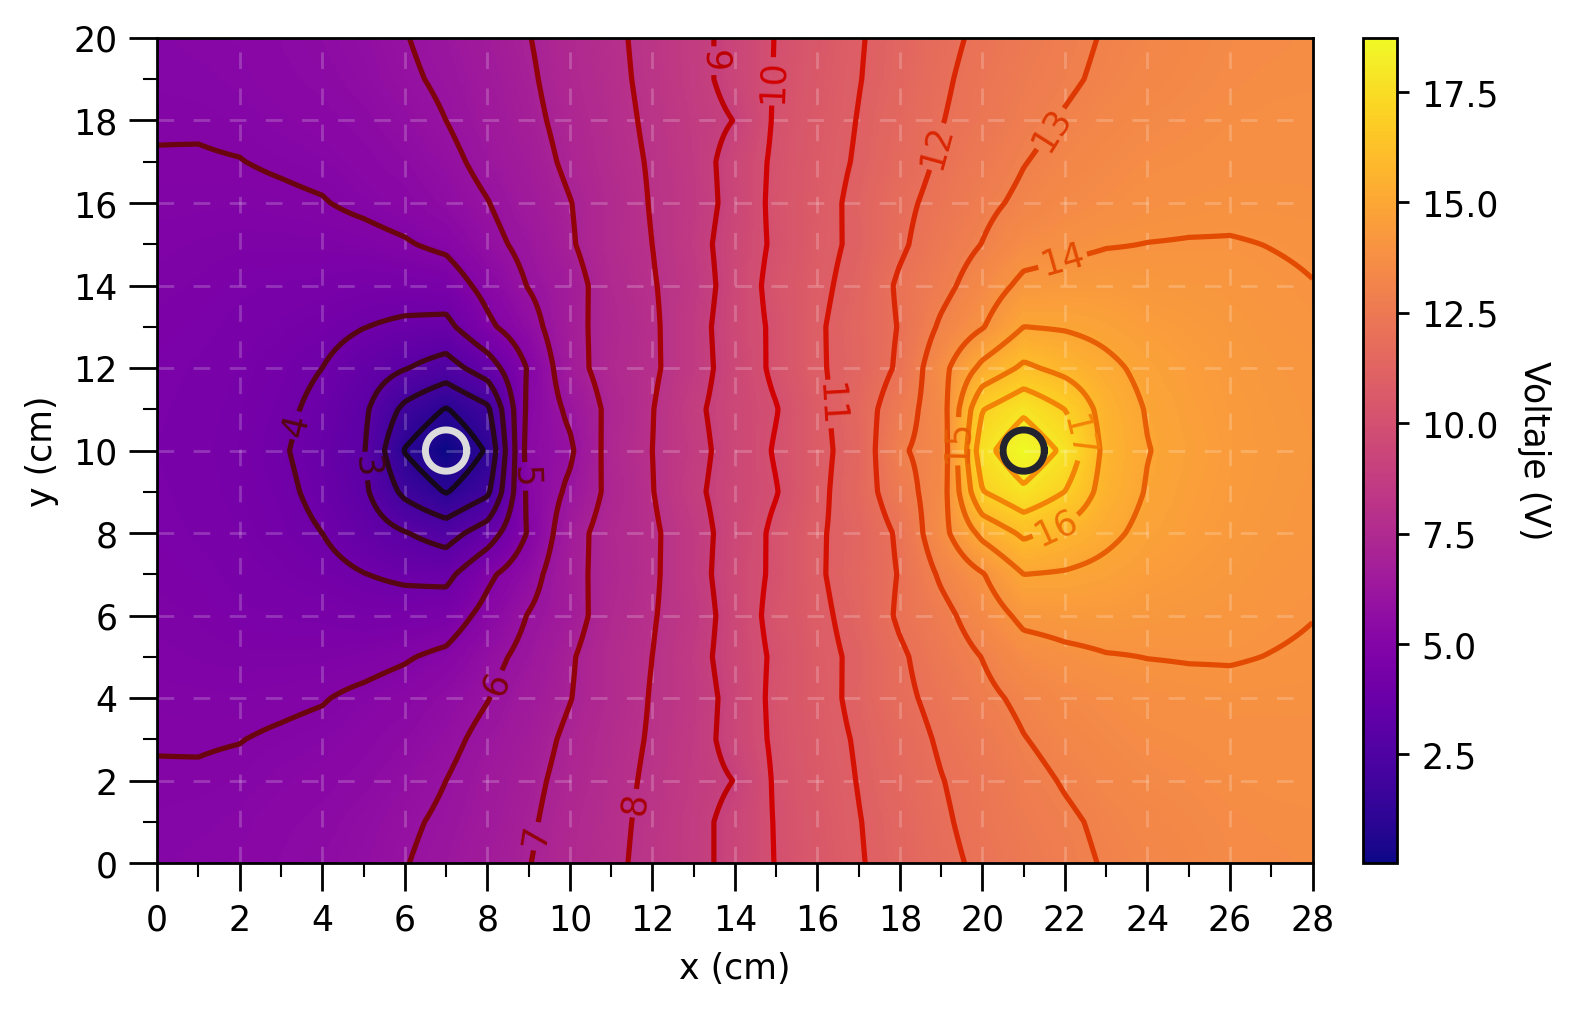

In [139]:
chargePositions = np.array([[7,10],[21,10]])
chargeColors = ["gainsboro","#232330"]

fig, ax = plt.subplots(dpi = 250)
divider = make_axes_locatable(ax)


levels = np.linspace(0,20,21)

img = ax.imshow(data, aspect='equal', cmap = "plasma", origin = "lower", interpolation = "nearest", extent = (0,28,0,20))
CS = ax.contour(X, Y, data, levels = levels, cmap = red_orange_cmap, zorder = 2)
ax.clabel(CS, levels[3:-3], fontsize = 10)

#ax.scatter(chargePositions[:,0], chargePositions[:,1], c = chargeColors, zorder = 15)

theta = np.linspace(0, 2*np.pi, 400)
plt.plot(7 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "gainsboro", linewidth=2)
plt.plot(21 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "#232330", linewidth=2)


cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(img, cax=cax)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)


ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#FFFFFF", zorder = 1, alpha = 0.2, ls = (0,(6,7)))

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
'''
cax = divider.append_axes("right", size="3%", pad=0.0)
cbar = plt.colorbar(sc, cax=cax)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)'''


plt.savefig("casoUnoEquipotencialesDipolo.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()

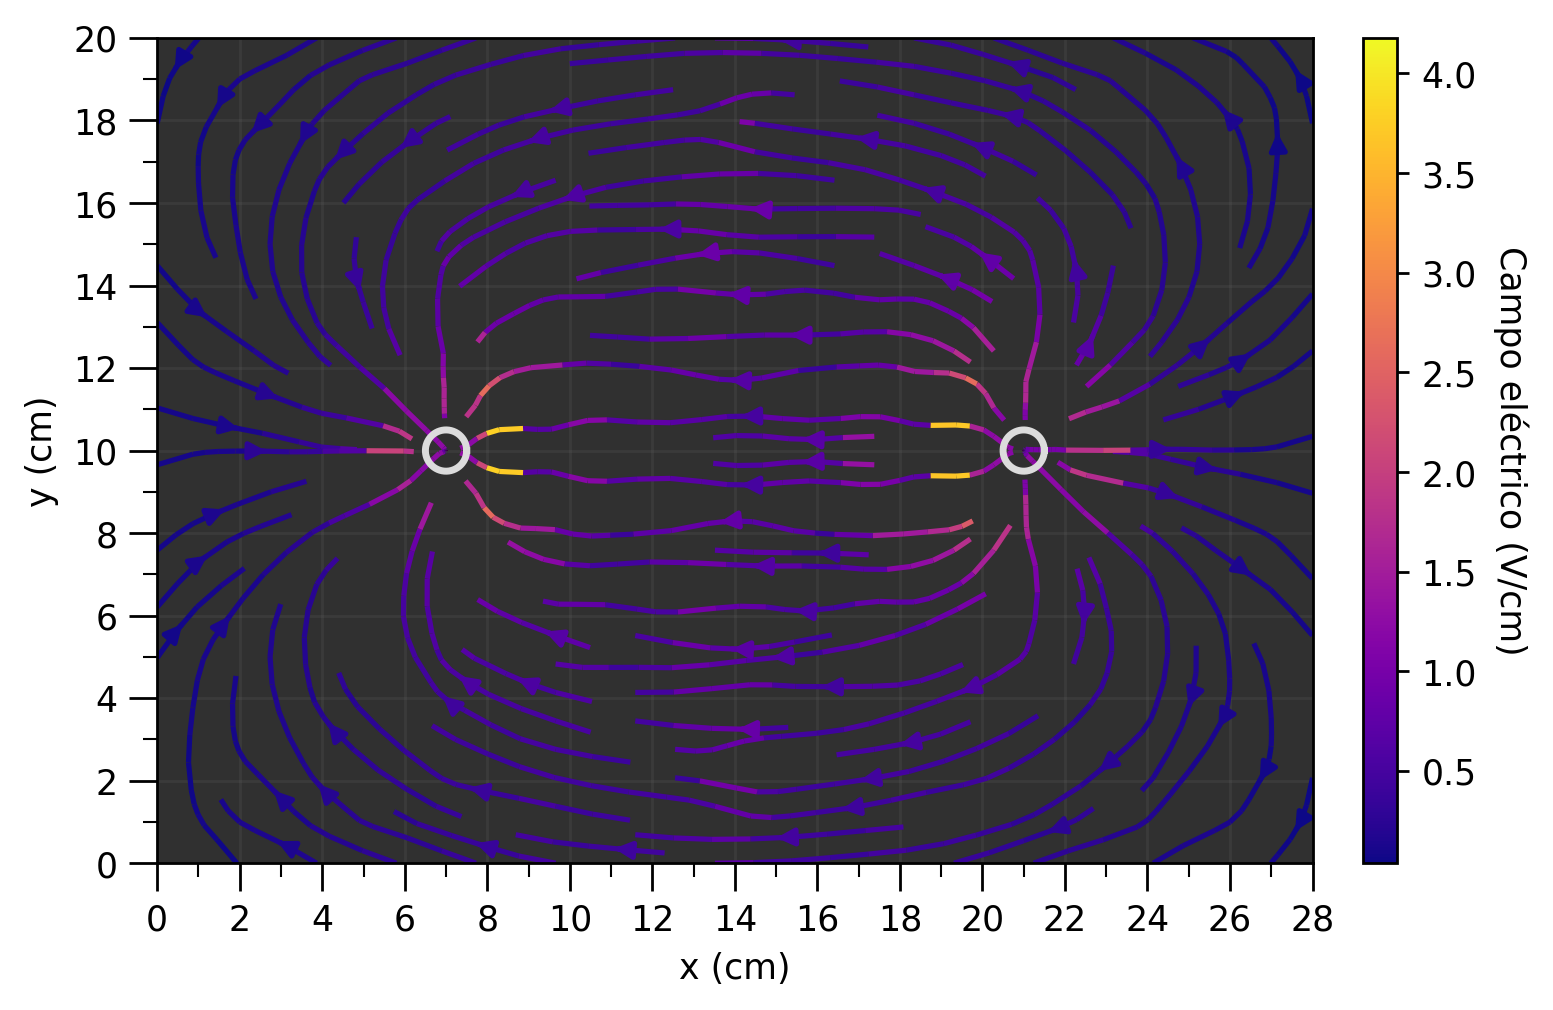

In [140]:
fig, ax = plt.subplots(dpi = 250)

divider = make_axes_locatable(ax)


isStreamlineBroken = True

normalizationFactor = np.max(fieldGradient[1]*fieldGradient[0])

stream = plt.streamplot(X,Y, fieldGradient[1], fieldGradient[0],
               color = np.sqrt(fieldGradient[1]**2+fieldGradient[0]**2),
               density = 1, cmap = "plasma",
               broken_streamlines = isStreamlineBroken,
               )
#ax.scatter(chargePositions[:,0], chargePositions[:,1], c = "gainsboro", zorder = 10)

theta = np.linspace(0, 2*np.pi, 400)
plt.plot(7 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "gainsboro", linewidth=2)
plt.plot(21 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "gainsboro", linewidth=2)

cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(stream.lines, cax=cax)
cbar.set_label('Campo eléctrico (V/cm)',rotation=-90,  labelpad=15)

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")

ax.set_facecolor('#303030')


plt.savefig(f"casoUnoCampoElectricoDipolo{isStreamlineBroken}.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()

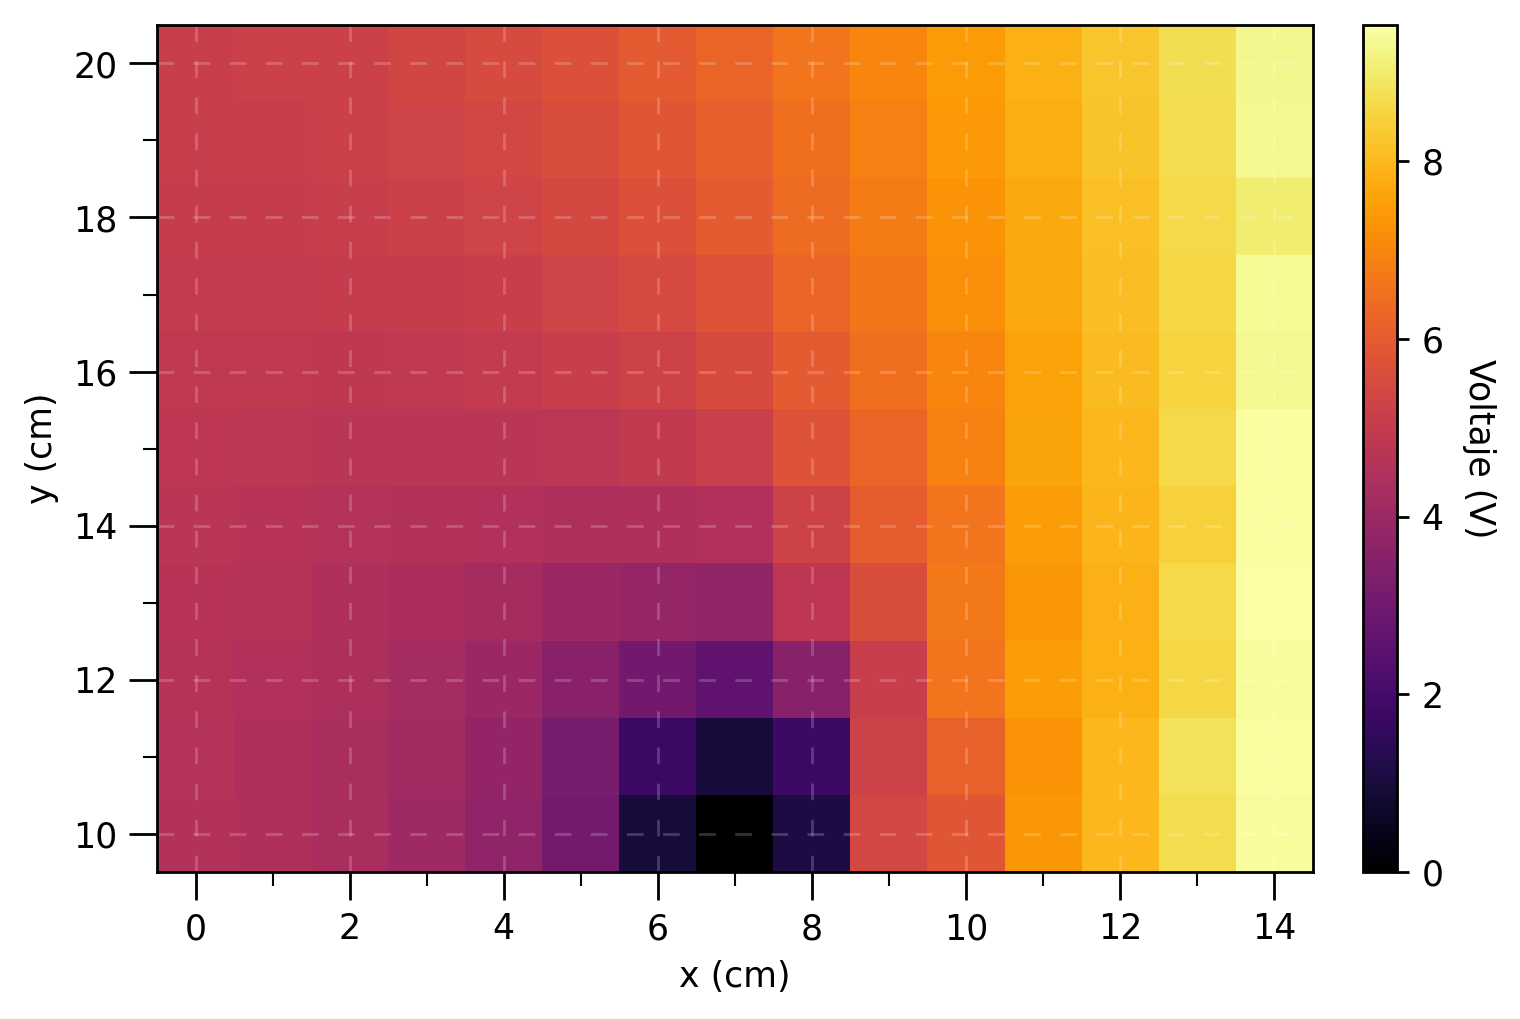

In [141]:
fig, ax = plt.subplots(dpi = 250)
divider = make_axes_locatable(ax)

offsetX = 0
offsetY = 10

img = ax.imshow(dataArray, aspect='equal', cmap = "inferno", origin = "upper", interpolation = "none", extent = (-0.5+offsetX,14.5+offsetX,-0.5+offsetY,10.5+offsetY))


cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(img, cax=cax)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)


ax.set_xticks(np.arange(0+offsetX, 15+offsetX, 2))
ax.set_xticks(np.arange(1+offsetX, 15+offsetX, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0+offsetY, 11+offsetY, 2))
ax.set_yticks(np.arange(1+offsetY, 11+offsetY, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#FFFFFF", zorder = 1, alpha = 0.2, ls = (0,(6,7)))

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

plt.savefig("casoUnoPreprocesado.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)

plt.show()

In [142]:
normMatrix = np.sqrt(fieldGradient[1]**2 + fieldGradient[0]**2)
normalizedFieldGradientU = fieldGradient[1]/normMatrix
normalizedFieldGradientV = fieldGradient[0]/normMatrix

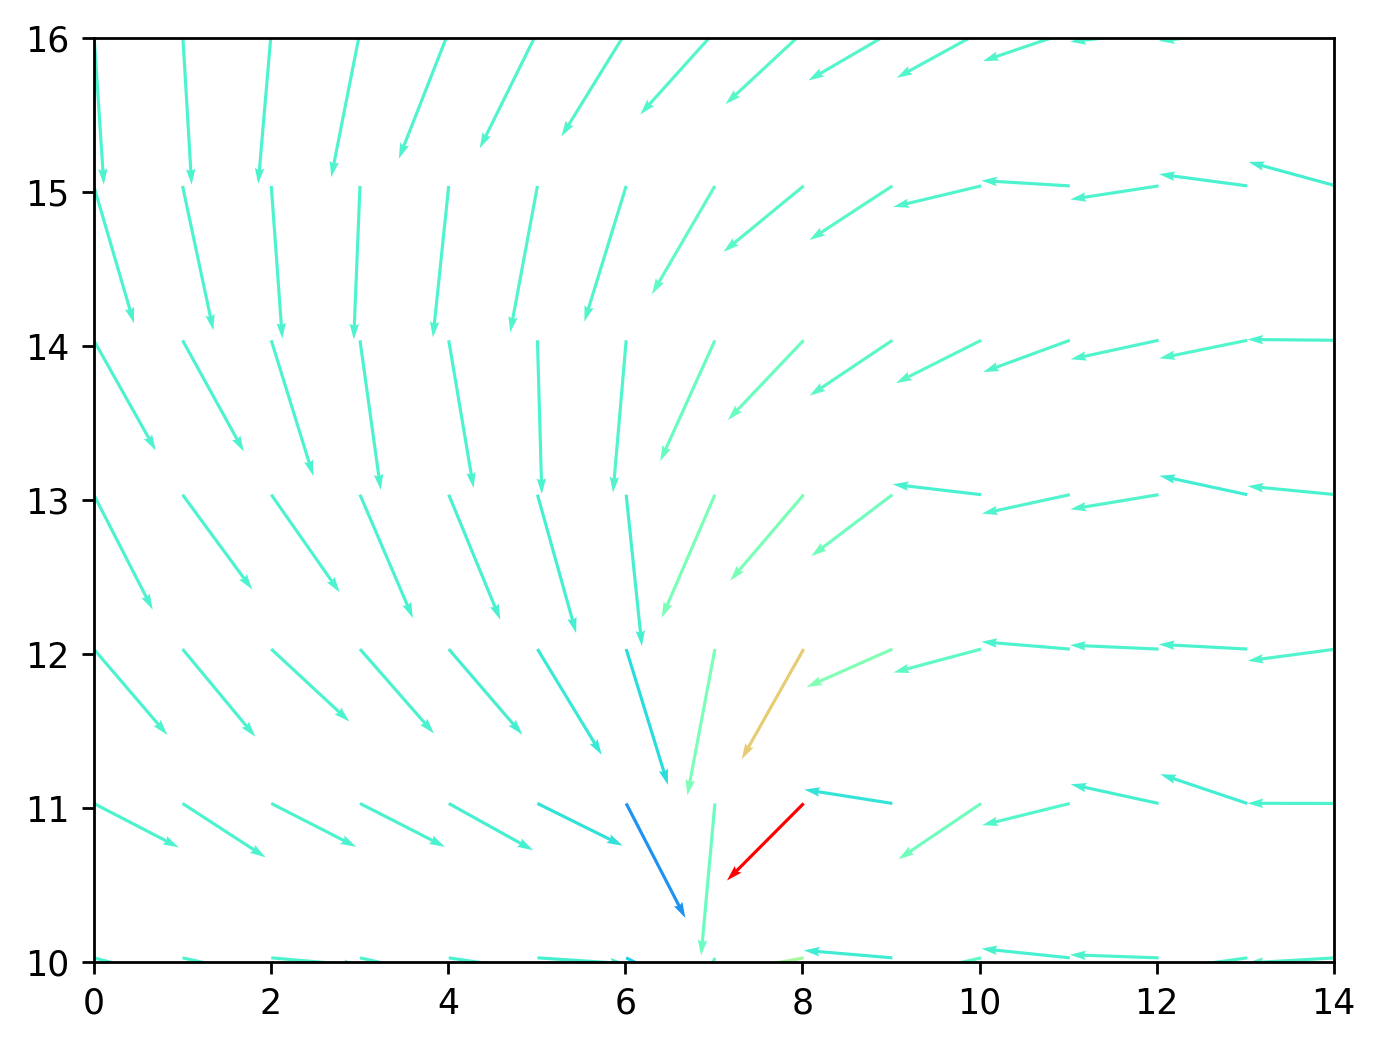

In [143]:
fig, ax = plt.subplots(dpi = 250)

skip = (slice(None, None, 20), slice(None, None, 20))
ax.quiver(X[skip],Y[skip], normalizedFieldGradientU[skip], normalizedFieldGradientV[skip], fieldGradient[1][skip]*fieldGradient[0][skip], angles='xy', scale_units='xy', scale = 1, cmap = 'rainbow')#, pivot = "mid")

ax.set_xlim(0,14)
ax.set_ylim(10,16)

plt.show()